<a href="https://colab.research.google.com/github/datadigger01/AppStatMat/blob/main/AppMatStat_Scaling_2wk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/datadigger01/AppStatMat/main/Data/WestRoxbury.csv"
filename = "WestRoxbury.csv"

# Download the file
response = requests.get(url)
if response.status_code == 200:
    with open(filename, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded {filename}")

    # Read the CSV into a pandas DataFrame
    df = pd.read_csv(filename)
    display(df.head())
else:
    print(f"Failed to download {filename}. Status code: {response.status_code}")

Downloaded WestRoxbury.csv


,TOTAL VALUE,TAX,LOT SQFT,YR BUILT,GROSS AREA,LIVING AREA,FLOORS,ROOMS,BEDROOMS,FULL BATH,HALF BATH,KITCHEN,FIREPLACE,REMODEL
0,344.2,4330,9965,1880,2436,1352,2.0,6,3,1,1,1,0,NaN
1,412.6,5190,6590,1945,3108,1976,2.0,10,4,2,1,1,0,Recent
2,330.1,4152,7500,1890,2294,1371,2.0,8,4,1,1,1,0,NaN
3,498.6,6272,13773,1957,5032,2608,1.0,9,5,1,1,1,1,NaN
4,331.5,4170,5000,1910,2370,1438,2.0,7,3,2,0,1,0,NaN


### 컬럼명 변경(공간제거)

In [ ]:
df.columns = df.columns.str.replace(' ', '')
df.head()

,TOTALVALUE,TAX,LOTSQFT,YRBUILT,GROSSAREA,LIVINGAREA,FLOORS,ROOMS,BEDROOMS,FULLBATH,HALFBATH,KITCHEN,FIREPLACE,REMODEL
0,344.2,4330,9965,1880,2436,1352,2.0,6,3,1,1,1,0,NaN
1,412.6,5190,6590,1945,3108,1976,2.0,10,4,2,1,1,0,Recent
2,330.1,4152,7500,1890,2294,1371,2.0,8,4,1,1,1,0,NaN
3,498.6,6272,13773,1957,5032,2608,1.0,9,5,1,1,1,1,NaN
4,331.5,4170,5000,1910,2370,1438,2.0,7,3,2,0,1,0,NaN


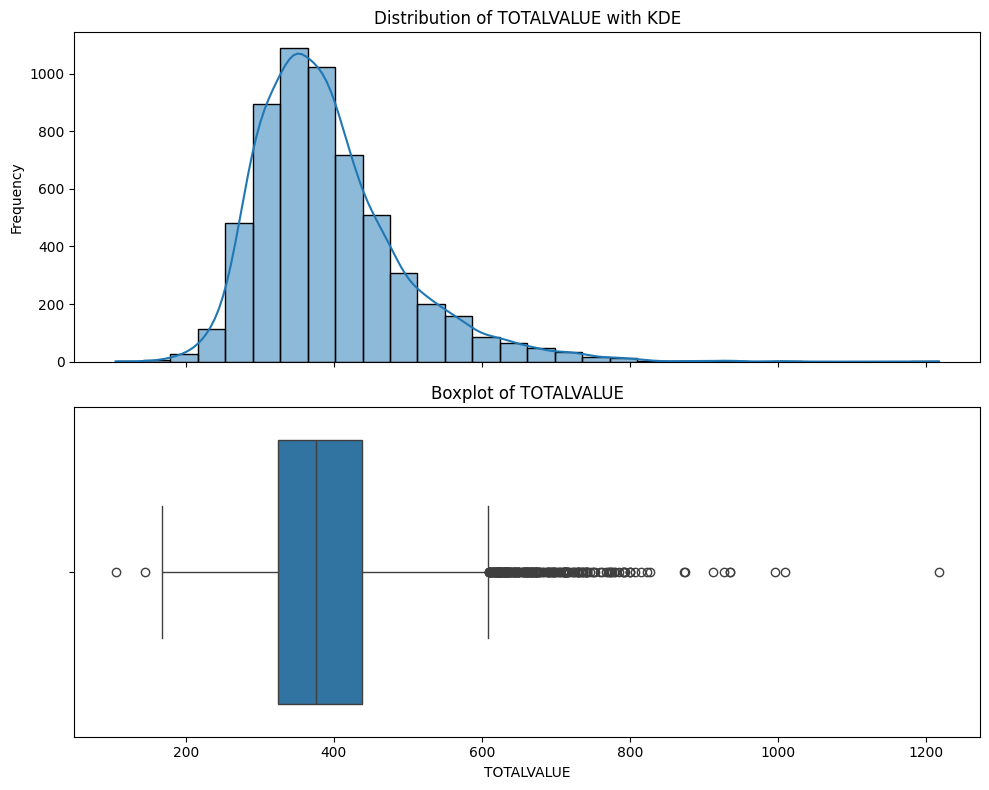

In [ ]:
#TOTALVALUE 컬럼을 대상으로 하여 막대그래프를 그리고 그 위에 분포선을 그려주세요.#
#위의 막대그래프와 Boxplot을 1열로 그리되 X축을 동일하게 맞추어 그려주세요#

import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots arranged in a column
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot the histogram on the first subplot
sns.histplot(df['TOTALVALUE'], kde=True, bins=30, ax=axes[0])
axes[0].set_title('Distribution of TOTALVALUE with KDE')
axes[0].set_ylabel('Frequency')

# Plot the boxplot on the second subplot
sns.boxplot(x=df['TOTALVALUE'], ax=axes[1])
axes[1].set_title('Boxplot of TOTALVALUE')
axes[1].set_xlabel('TOTALVALUE')

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()
plt.show()

In [ ]:
df

,TOTALVALUE,TAX,LOTSQFT,YRBUILT,GROSSAREA,LIVINGAREA,FLOORS,ROOMS,BEDROOMS,FULLBATH,HALFBATH,KITCHEN,FIREPLACE,REMODEL
0,344.2,4330,9965,1880,2436,1352,2.0,6,3,1,1,1,0,NaN
1,412.6,5190,6590,1945,3108,1976,2.0,10,4,2,1,1,0,Recent
2,330.1,4152,7500,1890,2294,1371,2.0,8,4,1,1,1,0,NaN
3,498.6,6272,13773,1957,5032,2608,1.0,9,5,1,1,1,1,NaN
4,331.5,4170,5000,1910,2370,1438,2.0,7,3,2,0,1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5797,404.8,5092,6762,1938,2594,1714,2.0,9,3,2,1,1,1,Recent
5798,407.9,5131,9408,1950,2414,1333,2.0,6,3,1,1,1,1,NaN
5799,406.5,5113,7198,1987,2480,1674,2.0,7,3,1,1,1,1,NaN
5800,308.7,3883,6890,1946,2000,1000,1.0,5,2,1,0,1,0,NaN


#### 정규화(Normalization) : 변수의 최대값과 최소값을 기준으로 보통 0과 1사이의 값으로 스케일 조정
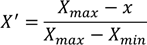


표준화(Standization) : 변수의 값들의 전체평균은 0, 분산은 1로 변환

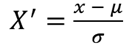


In [ ]:
"TOTALVALUE 컬럼에 대해서 표준호와 정규화된 2개의 컬럼을 생성하고 기존의 TOTALVALUE 컬럼도 그대로 보존되게 데이터셋을 재구성해주세요."

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Standardize the 'TOTALVALUE' column
scaler_standard = StandardScaler()
df['TOTALVALUE_standardized'] = scaler_standard.fit_transform(df[['TOTALVALUE']])

# Normalize the 'TOTALVALUE' column
scaler_minmax = MinMaxScaler()
df['TOTALVALUE_normalized'] = scaler_minmax.fit_transform(df[['TOTALVALUE']])

# Display the updated DataFrame with the new columns
df[['TOTALVALUE', 'TOTALVALUE_standardized', 'TOTALVALUE_normalized']].head()

,TOTALVALUE,TOTALVALUE_standardized,TOTALVALUE_normalized
0,344.2,-0.488921,0.214953
1,412.6,0.200812,0.276420
2,330.1,-0.631102,0.202283
3,498.6,1.068020,0.353702
4,331.5,-0.616985,0.203541


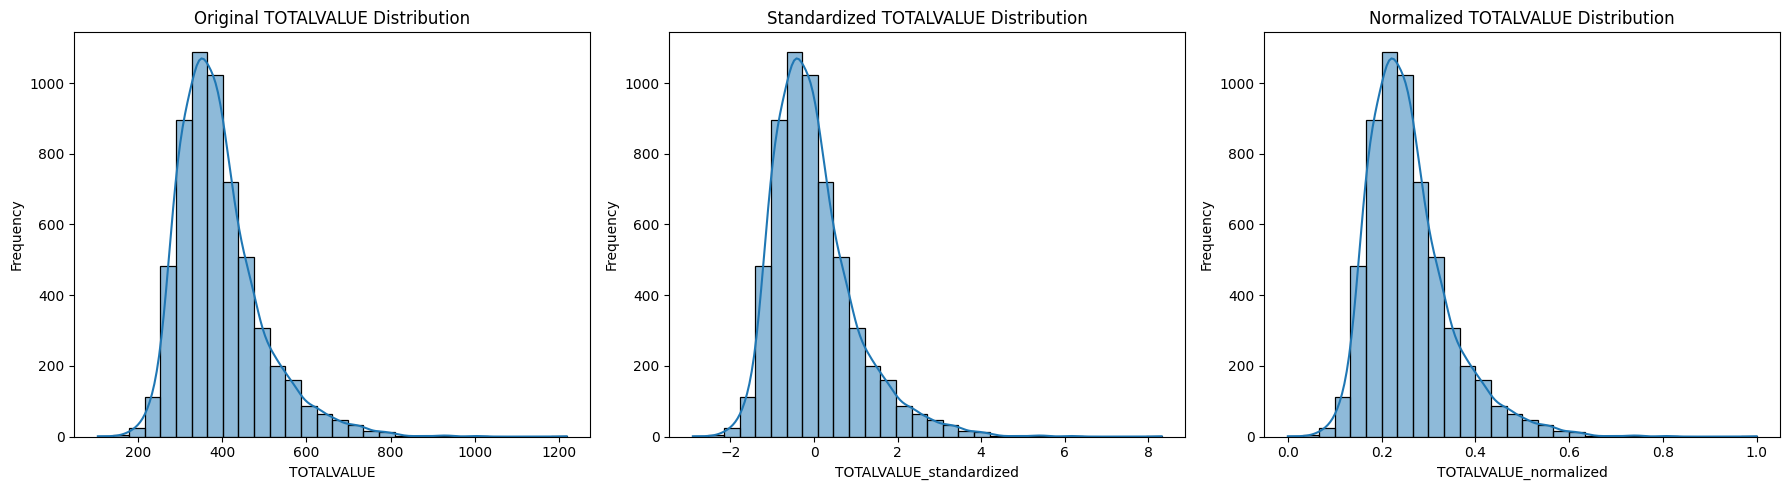

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with three subplots arranged in a row
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot the histogram and KDE for the original TOTALVALUE
sns.histplot(df['TOTALVALUE'], kde=True, bins=30, ax=axes[0])
axes[0].set_title('Original TOTALVALUE Distribution')
axes[0].set_xlabel('TOTALVALUE')
axes[0].set_ylabel('Frequency')

# Plot the histogram and KDE for the standardized TOTALVALUE
sns.histplot(df['TOTALVALUE_standardized'], kde=True, bins=30, ax=axes[1])
axes[1].set_title('Standardized TOTALVALUE Distribution')
axes[1].set_xlabel('TOTALVALUE_standardized')
axes[1].set_ylabel('Frequency')

# Plot the histogram and KDE for the normalized TOTALVALUE
sns.histplot(df['TOTALVALUE_normalized'], kde=True, bins=30, ax=axes[2])
axes[2].set_title('Normalized TOTALVALUE Distribution')
axes[2].set_xlabel('TOTALVALUE_normalized')
axes[2].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()

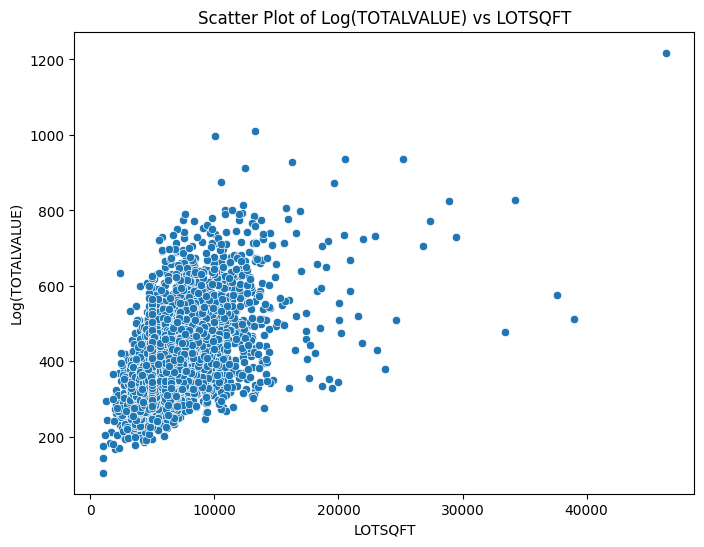

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['LOTSQFT'], y=df['TOTALVALUE'])
plt.title('Scatter Plot of Log(TOTALVALUE) vs LOTSQFT')
plt.xlabel('LOTSQFT')
plt.ylabel('Log(TOTALVALUE)')
plt.show()